# 第 12 章实战 · 生成模型：高斯采样、ELBO、GAN、扩散与 CFG

> 对应正文：[第 12 章目录](../docs/5-前沿与融合/12-生成模型与多模态/README.md) · [生成模型全景](../docs/5-前沿与融合/12-生成模型与多模态/01-生成模型全景.md) · [对抗生成网络GAN](../docs/5-前沿与融合/12-生成模型与多模态/02-对抗生成网络GAN.md) · [扩散模型Diffusion](../docs/5-前沿与融合/12-生成模型与多模态/03-扩散模型Diffusion.md)

本 notebook 把正文的"动手试试"与"数学深潜"扩展成 6 个可复现实验：

1. **高斯拟合采样**——最朴素的生成模型：2D 数据拟合高斯再采样，"生成 = 从分布抽样"；
2. **ELBO 下界可视化**——1D 双高斯混合的 ELBO 与 $\log p(x)$ 差距（Jensen 深潜可跑版：gap = KL 恰好对账）；
3. **最小 GAN**——torch 参考实现（语法校验 + 本地预期）+ numpy 复刻"伪 GAN"交替最小化（实跑）；
4. **前向扩散复现**——正文 β = 0.3 三步加噪数字打印 + 闭式公式验证 + 100 点云逐步变高斯（呼应 [playground/diffusion.html](../playground/diffusion.html)）；
5. **解析后验去噪**——GMM 的 Tweedie 后验均值一步去噪 + 恒等式数值验证（正文闭式公式可跑版）；
6. **温度与 CFG**——合成双峰"条件"分布下 CFG 权重 w 的偏移效果 + 温度对采样分布的锐化/平滑。

**环境**：`numpy` / `matplotlib` 直接运行；实验 3a 的 torch 版需本地 `pip install torch`（本 notebook 构建环境 torch DLL 不可用，该单元格只做语法校验）。随机种子固定，输出可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]   # 图表中文
plt.rcParams["axes.unicode_minus"] = False                        # 负号正常显示
import logging
logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)  # SimHei 缺数学负号字形，降噪告警

print("环境就绪：numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

环境就绪：numpy 1.26.4 | matplotlib 3.10.8


## 实验一：高斯拟合采样——最朴素的生成模型

**目标**（对应 [生成模型全景 · 动手试试 实验一](../docs/5-前沿与融合/12-生成模型与多模态/01-生成模型全景.md)）："生成 = 学会从分布中抽样"的最小现场——2 维高斯数据世界（斜着的椭圆点云）用极大似然拟合：均值与协方差有解析解（样本均值 / 样本协方差），再从拟合出的分布采样"生成"新样本。**新样本既像训练数据（落在云里），又不是抄训练数据（不是旧点）**——深度生成模型（VAE/GAN/Diffusion）干的是同一件事，只是把"高斯拟合"换成神经网络、把 2 维换成几百万维。

真实参数：均值 [2, 1]，协方差 [[1, 0.8], [0.8, 1]]
估计均值： [2.03  1.005]
估计协方差：
[[1.07  0.788]
 [0.788 0.896]]

训练点两两平均距离   = 1.667
生成-训练点平均距离   = 1.669
生成点与训练点几乎一样近——落在同一片'云'里，但不是旧点的复制（生成 = 采样，不是抄）。


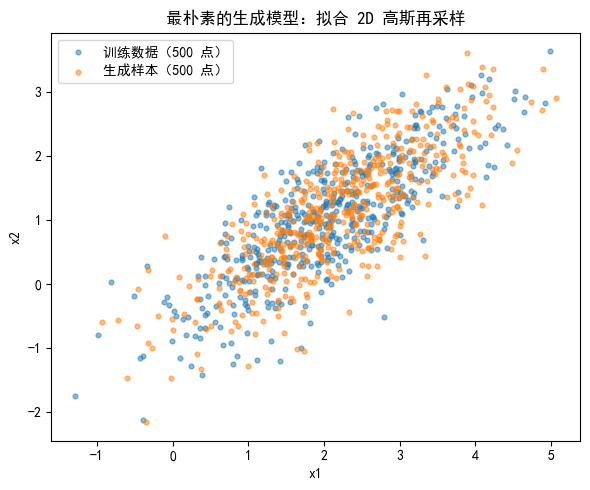

In [2]:
rng = np.random.default_rng(42)
true_mu = np.array([2.0, 1.0])
true_cov = np.array([[1.0, 0.8], [0.8, 1.0]])
X = rng.multivariate_normal(true_mu, true_cov, size=500)      # 500 个"真实样本"

mu_hat = X.mean(axis=0)                                        # 极大似然 = 样本均值
cov_hat = np.cov(X.T)                                          # 极大似然 = 样本协方差
print("真实参数：均值 [2, 1]，协方差 [[1, 0.8], [0.8, 1]]")
print("估计均值：", np.round(mu_hat, 3))
print("估计协方差：")
print(np.round(cov_hat, 3))

samples = rng.multivariate_normal(mu_hat, cov_hat, size=500)   # 从学到的分布里"生成"

d_train = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
d_cross = np.linalg.norm(samples[:, None, :] - X[None, :, :], axis=-1)
print(f"\n训练点两两平均距离   = {d_train[np.triu_indices(500, 1)].mean():.3f}")
print(f"生成-训练点平均距离   = {d_cross.mean():.3f}")
print("生成点与训练点几乎一样近——落在同一片'云'里，但不是旧点的复制（生成 = 采样，不是抄）。")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.5, label="训练数据（500 点）")
ax.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.5, label="生成样本（500 点）")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("最朴素的生成模型：拟合 2D 高斯再采样")
ax.legend()
fig.tight_layout()
plt.show()

**读数**：估计均值 ≈ [2, 1]、估计协方差 ≈ [[1, 0.8], [0.8, 1]]（500 样本的抽样误差内）；生成点云与训练点云重叠但位置不重合——两团点互相之间的平均距离与训练点彼此之间几乎相同。

**失败情形预告**（正文折叠框）：若协方差估得过大（椭圆画太胖），采出的新点会飘到点云外的空白区——"生成得像不像"完全取决于"分布学得准不准"，后面每一种模型的失败模式，归根到底都是这个问题在高维空间里的变体。

## 实验二：ELBO 下界可视化——Jensen 深潜可跑版

**目标**（对应 [生成模型全景 · 数学深潜：从 Jensen 到 ELBO](../docs/5-前沿与融合/12-生成模型与多模态/01-生成模型全景.md)）：精确恒等式

$$\log p(x) = \mathcal{L}_{\text{ELBO}}(q) + D_{\mathrm{KL}}\big(q(z \mid x)\,\big\|\,p_\theta(z \mid x)\big) \geq \mathcal{L}_{\text{ELBO}}(q)$$

取一个**隐变量只有两个取值**的模型（1D 双高斯混合），一切都能精确计算：$\log p(x)$、任意 $q$ 的 ELBO、真实后验、KL 差距。让 $q$ 在单纯形上扫一遍：ELBO 曲线永远在 $\log p(x)$ 横梁之下，恰在 $q = $ 真实后验处碰头；**每一点的 gap 都精确等于 $\mathrm{KL}(q \| p(z|x))$**——"下界与真值的差距被 KL 精确记账"。

观测 x = 1.0：log p(x) = -2.0939，真实后验 p(z=近端|x) = 0.9820

 q 的远端份额(mu=-2) ELBO       gap = log p(x) - ELBO    KL(q ‖ 真实后验)
    0.050       -2.1136          0.0196              0.0196
    0.300       -2.7012          0.6073              0.6073
    0.500       -3.4189          1.3250              1.3250
    0.018       -2.0939          0.0000              0.0000

扫描 2000 个 q：ELBO 峰值 = -2.0939，在远端份额 = 0.0181 处取得
——恰好等于真实后验的远端份额 0.0180；此处 gap = KL = 0，下界贴紧真值横梁。


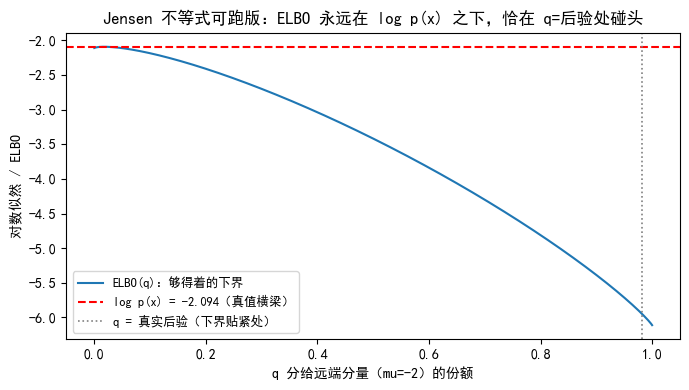

In [3]:
def norm_pdf(x, mu, var):
    return np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

x_obs = 1.0                                    # 观测到的数据点
mus = np.array([-2.0, 2.0])                    # 两个分量的均值
var = 1.0
prior = np.array([0.5, 0.5])                   # 先验：两个高斯各一半
joint = prior * norm_pdf(x_obs, mus, var)      # p(x, z)：z 离散，联合可精确算
log_px = np.log(joint.sum())                   # log p(x)：真目标
post = joint / joint.sum()                     # 真实后验 p(z|x)
far_share = 1 - post[1]                        # 后验分给远端分量(mu=-2)的份额
print(f"观测 x = {x_obs}：log p(x) = {log_px:.4f}，真实后验 p(z=近端|x) = {post[1]:.4f}")

def elbo(q):
    """ELBO(q) = E_q[log p(x,z) - log q]。"""
    return float(np.sum(q * (np.log(joint) - np.log(q))))

print("\n q 的远端份额(mu=-2) ELBO       gap = log p(x) - ELBO    KL(q ‖ 真实后验)")
for t in (0.05, 0.3, 0.5, far_share):
    q = np.array([t, 1 - t])
    kl = abs(np.sum(q * np.log(q / post)))   # 浮点噪声可能出现 -0.0000，取绝对值
    print(f"   {t:6.3f}      {elbo(q):8.4f}        {log_px - elbo(q):8.4f}            {kl:8.4f}")

ts = np.linspace(1e-4, 1 - 1e-4, 2000)
EL = np.array([elbo(np.array([t, 1 - t])) for t in ts])
print(f"\n扫描 2000 个 q：ELBO 峰值 = {EL.max():.4f}，在远端份额 = {ts[EL.argmax()]:.4f} 处取得")
print(f"——恰好等于真实后验的远端份额 {far_share:.4f}；此处 gap = KL = 0，下界贴紧真值横梁。")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, EL, label="ELBO(q)：够得着的下界")
ax.axhline(log_px, color="red", ls="--", label=f"log p(x) = {log_px:.3f}（真值横梁）")
ax.axvline(post[1], color="gray", ls=":", lw=1.2, label="q = 真实后验（下界贴紧处）")
ax.set_xlabel("q 分给远端分量（mu=-2）的份额")
ax.set_ylabel("对数似然 / ELBO")
ax.set_title("Jensen 不等式可跑版：ELBO 永远在 log p(x) 之下，恰在 q=后验处碰头")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**读数**：任意 $q$ 处 gap = KL 逐位相等（如远端份额 0.3 时 gap = 0.607 = KL = 0.607；观测 x=+1 离近端更近，最优 $q$ 把远端份额压到 0.018）——正文"精确分解"不再只是推导，是能打印的账本。

**与 VAE/Diffusion 的血缘**（统一视角）：VAE 用神经网络**学**一个 $q(z|x)$ 来把 ELBO 顶高；Diffusion 把 $q$ **钉死**为固定加噪工序（零参数），ELBO 化简成"猜噪声的 MSE"——同一行不等式的两种工程实现。优化时的坑也在这张图上：$q$ 和 $\theta$ 同时在动，横梁跟着吊床一起变形，"下界涨"未必"似然等量涨"。

## 实验三：最小 GAN——torch 参考版（语法校验）+ numpy 伪 GAN（实跑）

**3a. torch 参考实现**（对应 [GAN · 动手试试](../docs/5-前沿与融合/12-生成模型与多模态/02-对抗生成网络GAN.md)）：2D 玩具环形点云上训 GAN——判别器 D 学"真=1/假=0"（BCE），生成器 G 学"让 D 把假样本判真"（非饱和损失），交替训练 3000 步。健康读数：`D(真)`、`D(假)` 都逐渐靠近 0.5（博弈均衡）、生成点均值 ≈ (2, 2)、到中心距离 ≈ 2.0（环半径）、8 个扇区大致均匀。本构建环境 torch DLL 不可用，单元格只做语法校验——本地 `pip install torch` 后把 `RUN_GAN = True` 即可实跑（CPU 上约 1 分钟）。

**3b. numpy 伪 GAN**（实跑）：把"交替最小化的对抗博弈"剥到骨架——目标分布为 1D 双峰混合（均值 ±2），生成器退化为线性变换 $G(z) = wz + b$，判别器退化为二次特征逻辑回归。交替：D 梯度上升学分辨真假 → G 沿"让 D 判真"的方向梯度上升。看 $w \to \sqrt{5} \approx 2.236$（匹配总方差）、$b \to 0$（匹配均值）、D 判对率回落 0.5（均衡）。

In [4]:
RUN_GAN = False   # <- 本地装好 torch 后改为 True（CPU 约 1 分钟）

try:
    import torch
    import torch.nn as nn
    HAS_TORCH = True
except Exception as e:
    HAS_TORCH = False
    print(f"[提示] 导入 torch 失败（{type(e).__name__}），跳过 GAN 训练。")
    print("       本地复现：pip install torch，然后把 RUN_GAN 改为 True。")

if RUN_GAN and HAS_TORCH:
    torch.manual_seed(0)

    def sample_real(n):
        ang = torch.rand(n) * 2 * torch.pi
        r = 2.0 + 0.1 * torch.randn(n)
        return torch.stack([r * torch.cos(ang), r * torch.sin(ang)], dim=1) + 2.0   # 环形点云

    G = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
    D = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(),
                      nn.Linear(64, 1), nn.Sigmoid())
    optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))   # beta1=0.5 是 GAN 老传统
    optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    for step in range(3000):
        real = sample_real(128)
        fake = G(torch.randn(128, 2)).detach()            # detach：训练 D 时切断 G 的梯度
        lossD = bce(D(real), torch.ones(128, 1)) + bce(D(fake), torch.zeros(128, 1))
        optD.zero_grad(); lossD.backward(); optD.step()
        fake = G(torch.randn(128, 2))
        lossG = bce(D(fake), torch.ones(128, 1))          # 非饱和损失：让 D 把假样本判真
        optG.zero_grad(); lossG.backward(); optG.step()
        if step % 500 == 0:
            with torch.no_grad():
                dr = D(sample_real(256)).mean().item()
                df = D(G(torch.randn(256, 2))).mean().item()
            print(f"step {step:4d} | lossD={lossD.item():.3f} lossG={lossG.item():.3f}"
                  f" | D(真)={dr:.2f} D(假)={df:.2f}")
    with torch.no_grad():
        pts = G(torch.randn(1000, 2))
    print("生成点均值:", pts.mean(0).tolist(), "  应接近 [2.0, 2.0]")
    print("到中心平均距离:", (pts - 2).norm(dim=1).mean().item(), "  应接近 2.0（环半径）")
    # 本地预期：D 对真假打分徘徊 0.5 附近；模式崩塌检查（8 扇区直方图）大致均匀
elif HAS_TORCH:
    print("[提示] RUN_GAN = False，未训练。本地预期：D(真)/D(假)→0.5，生成点均匀落在环形上。")

[提示] 导入 torch 失败（OSError），跳过 GAN 训练。
       本地复现：pip install torch，然后把 RUN_GAN 改为 True。


iter    1: w = +0.504, b = +2.002 | G 样本均值 = +2.001, 标准差 = 0.506 | D 判对率 真/假 = 0.48/1.00


iter 1000: w = +2.230, b = +0.011 | G 样本均值 = +0.281, 标准差 = 2.133 | D 判对率 真/假 = 0.45/0.68


iter 2000: w = +2.230, b = +0.004 | G 样本均值 = +0.212, 标准差 = 2.238 | D 判对率 真/假 = 0.51/0.50


iter 3000: w = +2.237, b = +0.004 | G 样本均值 = -0.257, 标准差 = 2.283 | D 判对率 真/假 = 0.51/0.60


iter 4000: w = +2.221, b = +0.019 | G 样本均值 = -0.001, 标准差 = 2.166 | D 判对率 真/假 = 0.86/0.16

目标分布：均值 0（双峰对称），总标准差 = sqrt(1 + 4) = 2.236
读数：b -> 0（均值被 D 逼着对齐）、w -> 2.2 上下（方差被逼着对齐）、
D 判对率回落到 0.5 附近——两网络互相逼强的均衡；偶尔 D 又占上风再被打回，
正是 GAN 训练'目标非平稳、易振荡'的微缩版（G 优化的考卷每步都被 D 重新定义）。


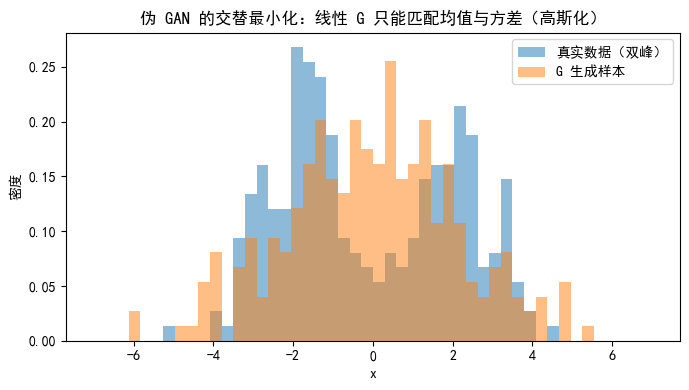

In [5]:
# 3b numpy 伪 GAN：交替最小化的"对抗博弈"骨架（全部解析求导）
rng = np.random.default_rng(0)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

w, b = 0.5, 2.0                          # 生成器 G(z) = w*z + b（初始错得很远）
d_coef = np.zeros(3)                     # 判别器 D(x) = sigmoid(d0 + d1*x + d2*x^2)
                                        # （二次特征让它能"看见"方差，不然只能看见均值）

for it in range(1, 4001):
    z = rng.normal(0, 1, 256)
    fake = w * z + b
    real = np.where(rng.random(256) < 0.5, -2.0, 2.0) + rng.normal(0, 1, 256)   # 目标：双峰混合
    # ---- 训练 D：真=1 假=0，逻辑回归梯度上升 ----
    feats = np.column_stack([np.ones(512), np.r_[real, fake], np.r_[real, fake] ** 2])
    lab = np.r_[np.ones(256), np.zeros(256)]
    for _ in range(30):
        p = sigmoid(feats @ d_coef)
        d_coef += 0.05 * feats.T @ (lab - p) / 512
    # ---- 训练 G：链式法则穿过 G，让 D 把假样本判真 ----
    p_fake = sigmoid(d_coef[0] + d_coef[1] * fake + d_coef[2] * fake ** 2)
    dDdx = (1 - p_fake) * (d_coef[1] + 2 * d_coef[2] * fake)   # d/dx [判真概率]
    w += 0.05 * np.mean(dDdx * z)                              # d(fake)/dw = z
    b += 0.05 * np.mean(dDdx)                                  # d(fake)/db = 1
    if it == 1 or it % 1000 == 0:
        accR = (sigmoid(feats[:256] @ d_coef) > 0.5).mean()
        accF = (sigmoid(feats[256:] @ d_coef) < 0.5).mean()
        print(f"iter {it:4d}: w = {w:+.3f}, b = {b:+.3f} | G 样本均值 = {fake.mean():+.3f},"
              f" 标准差 = {fake.std():.3f} | D 判对率 真/假 = {accR:.2f}/{accF:.2f}")

print("\n目标分布：均值 0（双峰对称），总标准差 = sqrt(1 + 4) = 2.236")
print("读数：b -> 0（均值被 D 逼着对齐）、w -> 2.2 上下（方差被逼着对齐）、")
print("D 判对率回落到 0.5 附近——两网络互相逼强的均衡；偶尔 D 又占上风再被打回，")
print("正是 GAN 训练'目标非平稳、易振荡'的微缩版（G 优化的考卷每步都被 D 重新定义）。")

fig, ax = plt.subplots(figsize=(7, 4))
grid = np.linspace(-7, 7, 400)
ax.hist(real, bins=48, range=(-7, 7), density=True, alpha=0.5, label="真实数据（双峰）")
ax.hist(fake, bins=48, range=(-7, 7), density=True, alpha=0.5, label="G 生成样本")
ax.set_xlabel("x")
ax.set_ylabel("密度")
ax.set_title("伪 GAN 的交替最小化：线性 G 只能匹配均值与方差（高斯化）")
ax.legend()
fig.tight_layout()
plt.show()

**读数**：伪 GAN 里 $w \to 2.2$、$b \to 0$——线性生成器被"对抗"逼到匹配目标的一、二阶矩；但双峰结构它**学不会**（线性变换只能把高斯变成高斯）——真实 GAN 的生成器是神经网络，才有能力匹配整个分布，代价是训练不稳定（正文：G 的优化目标每步都被 D 重新定义，"非平稳考卷"）。

**健康度读法**（3a 本地跑时对照）：`D(真)→1 且 D(假)→0 且 lossD→0` = G 断粮（D 太强，梯度消失）；两侧打分都贴 0.5 = 均衡；角度直方图个别扇区为 0 = 模式崩塌（"环上只剩几段有人"）。

## 实验四：前向扩散复现——β = 0.3 三步加噪 + 闭式公式验证 + 点云变高斯

**目标**（对应 [扩散模型 · 举个例子与深潜](../docs/5-前沿与融合/12-生成模型与多模态/03-扩散模型Diffusion.md)，交互版见 [playground/diffusion.html](../playground/diffusion.html)）：前向加噪规则 $x_t = \sqrt{1-\beta}\, x_{t-1} + \sqrt{\beta}\, \epsilon$。正文 8×8 笑脸、β = 0.3：系数 0.84 / 0.55 分别是 $\sqrt{0.7}$ 与 $\sqrt{0.3}$。三步看笑脸如何被噪声吞掉；再用闭式公式 $q(x_t \mid x_0) = \mathcal{N}(\sqrt{\bar\alpha_t}\, x_0,\ (1-\bar\alpha_t) I)$（$\bar\alpha_3 = 0.7^3 = 0.343$）做蒙特卡洛对账：**原 1 位置均值 ≈ 0.586、原 0 位置均值 ≈ 0**——"逐步循环加噪"与"一步到位"分布一致（独立高斯相加的归纳证明）。最后看 100 点云（环形）逐步加噪变高斯。

In [6]:
smiley = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]], dtype=float)          # 1 = 笔划，0 = 背景

BETA = 0.3
ALPHA = 1 - BETA

def show(mat, title):
    print(title)
    for row in mat:
        print("   " + " ".join(f"{v:+.2f}" for v in row))

show(smiley, "原始图 x0（1 = 笔划，0 = 背景）：")
rng = np.random.default_rng(42)
xt = smiley.copy()
for t in (1, 2, 3):
    xt = np.sqrt(ALPHA) * xt + np.sqrt(BETA) * rng.normal(0, 1, xt.shape)
    show(xt, f"\n加噪 {t} 步后的 x_{t}（x_t = 0.84*x_(t-1) + 0.55*eps，每次抽样不同）：")

abar3 = ALPHA ** 3
print(f"\n闭式验算：beta=0.3 三步 -> alpha_bar_3 = 0.7^3 = {abar3:.3f}，"
      f"即 x_3 ~ N({np.sqrt(abar3):.3f} * x0, {np.sqrt(1 - abar3):.3f}^2)")

# 蒙特卡洛对账：逐步加噪 vs 闭式分布
rng = np.random.default_rng(1)
ones_mask = smiley == 1
acc = np.zeros_like(smiley)
for _ in range(20000):
    acc += np.sqrt(abar3) * smiley + np.sqrt(1 - abar3) * rng.normal(0, 1, smiley.shape)
mean_map = acc / 20000
print(f"x_3 的'原 1 位置'平均 = {mean_map[ones_mask].mean():.3f}（理论 {np.sqrt(abar3):.3f}）")
print(f"x_3 的'原 0 位置'平均 = {mean_map[~ones_mask].mean():.3f}（理论 0）")
print("分布对上：几百步小噪声可'合并报销'成一个大噪声——训练时随机抽 t 一步造样本的合法性。")

原始图 x0（1 = 笔划，0 = 背景）：
   +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00
   +0.00 +1.00 +1.00 +0.00 +0.00 +1.00 +1.00 +0.00
   +0.00 +1.00 +1.00 +0.00 +0.00 +1.00 +1.00 +0.00
   +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00
   +0.00 +1.00 +0.00 +0.00 +0.00 +0.00 +1.00 +0.00
   +0.00 +0.00 +1.00 +0.00 +0.00 +1.00 +0.00 +0.00
   +0.00 +0.00 +0.00 +1.00 +1.00 +0.00 +0.00 +0.00
   +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00

加噪 1 步后的 x_1（x_t = 0.84*x_(t-1) + 0.55*eps，每次抽样不同）：
   +0.17 -0.57 +0.41 +0.52 -1.07 -0.71 +0.07 -0.17
   -0.01 +0.37 +1.32 +0.43 +0.04 +1.45 +1.09 -0.47
   +0.20 +0.31 +1.32 -0.03 -0.10 +0.46 +1.51 -0.08
   -0.23 -0.19 +0.29 +0.20 +0.23 +0.24 +1.17 -0.22
   -0.28 +0.39 +0.34 +0.62 -0.06 -0.46 +0.39 +0.36
   +0.41 +0.30 +0.47 +0.13 +0.06 +0.96 +0.48 +0.12
   +0.37 +0.04 +0.16 +1.18 +0.04 -0.18 -0.26 -0.35
   -0.15 +0.82 -0.47 +0.53 -0.92 -0.18 +0.09 +0.32

加噪 2 步后的 x_2（x_t = 0.84*x_(t-1) + 0.55*eps，每次抽样不同）：
   +0.53 -0.04 +0.15 +0.18 -0.42 -0.70 -0.64 -0.77
   -

加噪进度条（beta=0.3）：信号系数 sqrt(alpha_bar_t) 与噪声系数 sqrt(1-alpha_bar_t) 的'权力交接'
步数 t    信号系数    噪声系数
  1       0.837      0.548
  2       0.700      0.714
  3       0.586      0.811
  4       0.490      0.872
  5       0.410      0.912
  6       0.343      0.939


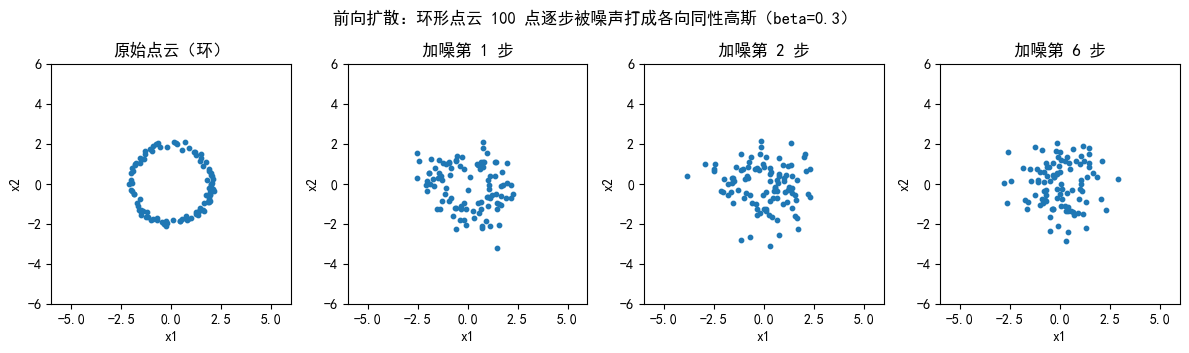

第 1 步还认得出环；第 2 步只剩痕迹；第 6 步已与标准高斯团难分——
信号系数降到 0.343、噪声系数升到 0.939，'破坏进度条'走完了权力交接。


In [7]:
# ---- 100 点云逐步变高斯（动画式多图）----
rng = np.random.default_rng(0)
ang = rng.uniform(0, 2 * np.pi, 100)
r = 2 + 0.1 * rng.normal(0, 1, 100)
cloud = np.column_stack([r * np.cos(ang), r * np.sin(ang)])     # 环形点云

print("加噪进度条（beta=0.3）：信号系数 sqrt(alpha_bar_t) 与噪声系数 sqrt(1-alpha_bar_t) 的'权力交接'")
print("步数 t    信号系数    噪声系数")
for t in range(1, 7):
    abar = ALPHA ** t
    print(f"  {t}       {np.sqrt(abar):.3f}      {np.sqrt(1 - abar):.3f}")

shown = {0: cloud.copy()}
cur = cloud.copy()
for t in range(1, 15):
    cur = np.sqrt(ALPHA) * cur + np.sqrt(BETA) * rng.normal(0, 1, cur.shape)
    shown[t] = cur.copy()

fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
for ax, t in zip(axes, (0, 1, 2, 6)):
    pts = shown[t]
    ax.scatter(pts[:, 0], pts[:, 1], s=10)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.set_title(f"加噪第 {t} 步" if t else "原始点云（环）")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
fig.suptitle("前向扩散：环形点云 100 点逐步被噪声打成各向同性高斯（beta=0.3）")
fig.tight_layout()
plt.show()

print("第 1 步还认得出环；第 2 步只剩痕迹；第 6 步已与标准高斯团难分——")
print("信号系数降到 %.3f、噪声系数升到 %.3f，'破坏进度条'走完了权力交接。" % (np.sqrt(ALPHA ** 6), np.sqrt(1 - ALPHA ** 6)))

**读数**：三步加噪后笑脸已与随机噪声难辨——眼睛失效，但统计上"原 1 位置均值仍略高"（0.586 vs 0），这丝微弱规律正是去噪网络要抓的东西；点云从环到高斯团的"融化"过程与 [playground/diffusion.html](../playground/diffusion.html) 的交互一致。

**训练高效的钥匙**：闭式公式让"随机抽一个步数 t、一步造出敲到任意进度的样本"成为免费操作——独立高斯相加仍是高斯（家族封闭性），选高斯不是审美，是唯一能这么方便算的常见分布。

## 实验五：解析后验去噪——GMM 的 Tweedie 后验均值一步去噪

**目标**（对应 [扩散模型 · 深潜"变分界 → 猜噪声"](../docs/5-前沿与融合/12-生成模型与多模态/03-扩散模型Diffusion.md) 的闭式 cousins）：真实扩散模型的去噪器 $\epsilon_\theta(x_t, t)$ 要用网络学；在**先验是可解析的 GMM** 时，最优去噪器有闭式——后验均值 $\mathbb{E}[x_0 \mid x_t]$（均方误差意义下的最优估计）。设先验 $x_0 \sim 0.5\mathcal{N}(-3,1) + 0.5\mathcal{N}(3,1)$，加噪 $x_t = \sqrt{\bar\alpha}\, x_0 + \sqrt{1-\bar\alpha}\, \epsilon$：

- 责任权重 $r_i(x_t) \propto \pi_i \, \mathcal{N}(x_t;\ \sqrt{\bar\alpha}\,\mu_i,\ 1)$（单位方差分量的巧合：噪声化后每个分量方差仍是 1）；
- 后验均值 $\hat x_0 = \sum_i r_i \big(\sqrt{\bar\alpha}\, x_t + (1 - \bar\alpha)\,\mu_i\big)$（向两个先验均值收缩）；
- 同时验证 **Tweedie 公式** $\mathbb{E}[x_0 \mid x_t] = \big(x_t + (1-\bar\alpha)\,\nabla_{x_t} \log p_t(x_t)\big) / \sqrt{\bar\alpha}$——"去噪器 = 得分函数的换装"，数值上应精确相等。

abar = 0.35（信号剩 0.592，噪声 0.806）：
  一步后验去噪 MSE      = 1.1080   <- 最优（MMSE 下界）
  不去噪直接用 x_t      = 2.3085
  闭眼猜全局均值 0      = 9.9435

Tweedie 公式 vs 解析后验均值：最大偏差 = 2.40e-10
—— 去噪器与得分函数是同一个量的两种参数化（扩散与 score-based 模型的共同地基）。


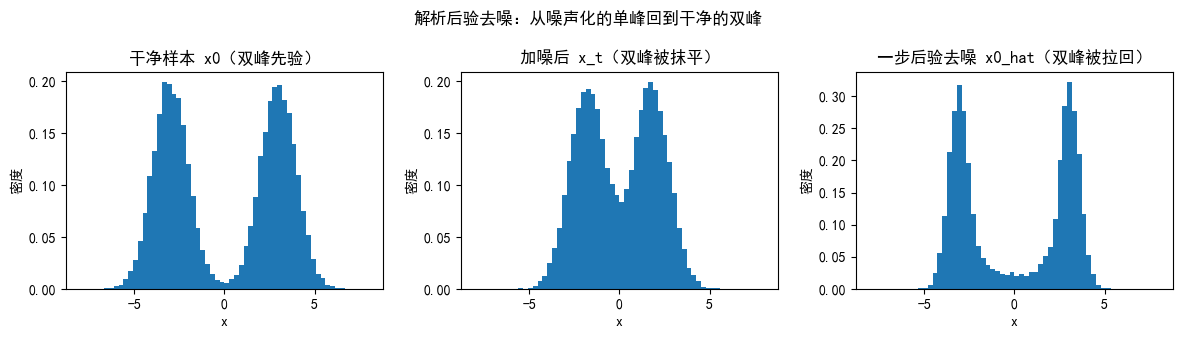

In [8]:
def norm_pdf(x, mu, var):
    return np.exp(-(x - mu) ** 2 / (2 * var)) / np.sqrt(2 * np.pi * var)

mus = np.array([-3.0, 3.0])
prior = np.array([0.5, 0.5])
ABAR = 0.35

rng = np.random.default_rng(0)
comp = rng.integers(0, 2, 20000)
x0 = mus[comp] + rng.normal(0, 1, 20000)                      # 从 GMM 采"干净样本"
xt = np.sqrt(ABAR) * x0 + np.sqrt(1 - ABAR) * rng.normal(0, 1, 20000)   # 一步加噪

def resp_denoise(xt_, prior_):
    """解析后验均值：责任加权 + 向先验均值收缩。"""
    w_i = prior_[:, None] * np.stack([norm_pdf(xt_, np.sqrt(ABAR) * mus[0], 1.0),
                                      norm_pdf(xt_, np.sqrt(ABAR) * mus[1], 1.0)])
    r = w_i / w_i.sum(0)
    return (r[0] * (np.sqrt(ABAR) * xt_ + (1 - ABAR) * mus[0])
            + r[1] * (np.sqrt(ABAR) * xt_ + (1 - ABAR) * mus[1]))

x0_hat = resp_denoise(xt, prior)
mse_hat = np.mean((x0_hat - x0) ** 2)          # 后验均值（MMSE 最优）
mse_raw = np.mean((xt - x0) ** 2)              # 基线：不去噪，直接把 x_t 当 x_0
mse_mean0 = np.mean(x0 ** 2)                   # 基线：闭眼猜全局均值 0
print(f"abar = {ABAR}（信号剩 {np.sqrt(ABAR):.3f}，噪声 {np.sqrt(1 - ABAR):.3f}）：")
print(f"  一步后验去噪 MSE      = {mse_hat:.4f}   <- 最优（MMSE 下界）")
print(f"  不去噪直接用 x_t      = {mse_raw:.4f}")
print(f"  闭眼猜全局均值 0      = {mse_mean0:.4f}")

# ---- Tweedie 恒等式验证：E[x0|xt] = (xt + (1-abar) * score(xt)) / sqrt(abar) ----
def p_t(x):
    return (prior[0] * norm_pdf(x, np.sqrt(ABAR) * mus[0], 1.0)
            + prior[1] * norm_pdf(x, np.sqrt(ABAR) * mus[1], 1.0))      # 噪声化后的混合密度

eps = 1e-5
score = (np.log(p_t(xt + eps)) - np.log(p_t(xt - eps))) / (2 * eps)     # 数值得分函数
tweedie = (xt + (1 - ABAR) * score) / np.sqrt(ABAR)
print(f"\nTweedie 公式 vs 解析后验均值：最大偏差 = {np.abs(tweedie - x0_hat).max():.2e}")
print("—— 去噪器与得分函数是同一个量的两种参数化（扩散与 score-based 模型的共同地基）。")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].hist(x0, bins=60, range=(-8, 8), density=True)
axes[0].set_title("干净样本 x0（双峰先验）")
axes[1].hist(xt, bins=60, range=(-8, 8), density=True)
axes[1].set_title("加噪后 x_t（双峰被抹平）")
axes[2].hist(x0_hat, bins=60, range=(-8, 8), density=True)
axes[2].set_title("一步后验去噪 x0_hat（双峰被拉回）")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("密度")
fig.suptitle("解析后验去噪：从噪声化的单峰回到干净的双峰")
fig.tight_layout()
plt.show()

**读数**：一步去噪把 MSE 从约 2.31 压到约 1.11（"闭眼猜均值 0"是 9.9——先验 ±3 的双峰方差约 10）——$x_t$ 的单峰分布被"收缩 + 责任加权"重新撕成双峰（第三张图）；Tweedie 恒等式在 $10^{-10}$ 量级精确成立。

**与真实扩散的对接**：DDPM 的网络 $\epsilon_\theta$ 学的正是把这份"后验均值"换算成"当初撒的噪声"（$\hat x_0 = (x_t - \sqrt{1-\bar\alpha}\,\epsilon_\theta)/\sqrt{\bar\alpha}$，等价参数化）；预测 $\epsilon$ 而不是 $x_0$，赢在目标统计性质（标准正态）不随 $t$ 变。

## 实验六：温度与 CFG——采样分布的两只旋钮

**目标**（对应 [扩散模型 · 条件生成 CFG 公式](../docs/5-前沿与融合/12-生成模型与多模态/03-扩散模型Diffusion.md) 与 [多模态 · 温度](../docs/5-前沿与融合/12-生成模型与多模态/04-多模态模型.md)）：把实验五的解析去噪器当"玩具扩散模型"，构造一个**合成双峰条件分布**——"左"提示的条件先验 = 0.8N(-2,1) + 0.2N(2,1)（八成听提示），无条件先验 = 0.5/0.5。两个旋钮：

- **CFG**：$\hat x_0^{\text{cfg}} = \hat x_0^{u} + w\,(\hat x_0^{c} - \hat x_0^{u})$——把"提示推动力"（条件 − 无条件）放大 $w$ 倍。$w$ 从 0 → 1 → 3 → 8：先不听话、再听话、再强化、最后**越过模式中心**（过饱和 / 烧图的一维版）；
- **温度**：采样密度 $p_T(x) \propto p(x)^{1/T}$——$T < 1$ 锐化（更集中在众数、更"笃定"），$T > 1$ 平滑（更容易跨模、更"发散"）。

In [9]:
ABAR = 0.35
mus2 = np.array([-2.0, 2.0])
prior_c = np.array([0.8, 0.2])     # 条件先验：'左'提示，八成听
prior_u = np.array([0.5, 0.5])     # 无条件先验

def cond_denoise(xt_, prior_):
    w_i = prior_[:, None] * np.stack([norm_pdf(xt_, np.sqrt(ABAR) * mus2[0], 1.0),
                                      norm_pdf(xt_, np.sqrt(ABAR) * mus2[1], 1.0)])
    r = w_i / w_i.sum(0)
    return (r[0] * (np.sqrt(ABAR) * xt_ + (1 - ABAR) * mus2[0])
            + r[1] * (np.sqrt(ABAR) * xt_ + (1 - ABAR) * mus2[1]))

xt_probe = np.array([-1.0, -0.3, 0.0, 0.3, 1.0])
xc = cond_denoise(xt_probe, prior_c)
xu = cond_denoise(xt_probe, prior_u)

print("CFG 外推：x0_hat_cfg = x0_hat_u + w * (x0_hat_c - x0_hat_u)   （提示 = '去左模'）")
print("  x_t    x0_hat_c   x0_hat_u |   w=0     w=1     w=3     w=8")
for k, xv in enumerate(xt_probe):
    row = "".join(f"{xu[k] + w * (xc[k] - xu[k]):+7.2f}" for w in (0, 1, 3, 8))
    print(f"{xv:+5.1f}   {xc[k]:+7.2f}   {xu[k]:+7.2f} |{row}")
print("\n读数：w=0 完全不听提示；w=1 纯条件生成；w=3 明显推向左模；")
print("w=8 已越过左模中心 -2（如 x_t=0 处被推到 -6.2）——'外推过头'的过饱和/构图僵硬的一维版。")
print("生产甜点区 w=3~7.5：更大开始'烧图'；每步两次前向（条件 + 无条件）是 CFG 的算力代价。")

CFG 外推：x0_hat_cfg = x0_hat_u + w * (x0_hat_c - x0_hat_u)   （提示 = '去左模'）
  x_t    x0_hat_c   x0_hat_u |   w=0     w=1     w=3     w=8
 -1.0     -1.83     -1.67 |  -1.67  -1.83  -2.16  -2.98
 -0.3     -1.19     -0.62 |  -0.62  -1.19  -2.34  -5.20
 +0.0     -0.78     +0.00 |  +0.00  -0.78  -2.34  -6.24
 +0.3     -0.25     +0.62 |  +0.62  -0.25  -1.98  -6.31
 +1.0     +1.18     +1.67 |  +1.67  +1.18  +0.21  -2.22

读数：w=0 完全不听提示；w=1 纯条件生成；w=3 明显推向左模；
w=8 已越过左模中心 -2（如 x_t=0 处被推到 -6.2）——'外推过头'的过饱和/构图僵硬的一维版。
生产甜点区 w=3~7.5：更大开始'烧图'；每步两次前向（条件 + 无条件）是 CFG 的算力代价。


温度采样（条件分布：左模 -2 名义占 80%）：
  温度 T    左模样本占比    样本标准差
    0.5        0.933         1.191
    1.0        0.787         1.892
    2.0        0.656         2.393

T<1 分布变尖：几乎全落在左模（更'笃定'，多样性下降）；
T>1 分布变平：跨模比例明显上升（更'发散'，容易采到没被提示指定的模）。


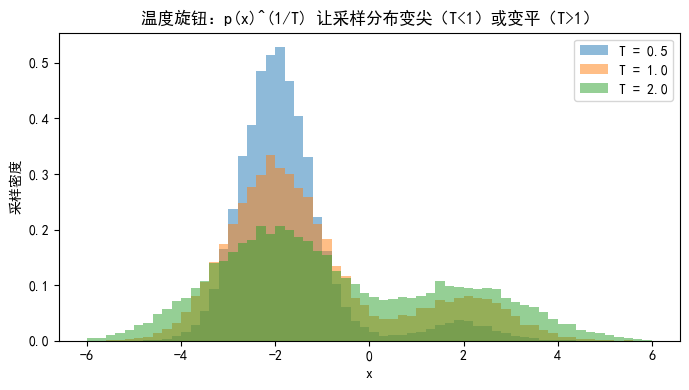

In [10]:
# ---- 温度：p_T(x) ∝ p(x)^(1/T)，对条件分布（左模占 80%）采样 ----
rng = np.random.default_rng(2)
grid = np.linspace(-6, 6, 2401)
p_cond = prior_c[0] * norm_pdf(grid, mus2[0], 1.0) + prior_c[1] * norm_pdf(grid, mus2[1], 1.0)

print("温度采样（条件分布：左模 -2 名义占 80%）：")
print("  温度 T    左模样本占比    样本标准差")
samples_by_T = {}
for T in (0.5, 1.0, 2.0):
    pw = p_cond ** (1.0 / T)
    pw = pw / pw.sum()
    cdf = np.cumsum(pw)
    s = grid[np.searchsorted(cdf, rng.random(20000))]
    samples_by_T[T] = s
    print(f"  {T:5.1f}     {(s < 0).mean():8.3f}      {s.std():8.3f}")
print("\nT<1 分布变尖：几乎全落在左模（更'笃定'，多样性下降）；")
print("T>1 分布变平：跨模比例明显上升（更'发散'，容易采到没被提示指定的模）。")

fig, ax = plt.subplots(figsize=(7, 4))
for T, s in samples_by_T.items():
    ax.hist(s, bins=60, range=(-6, 6), density=True, alpha=0.5, label=f"T = {T}")
ax.set_xlabel("x")
ax.set_ylabel("采样密度")
ax.set_title("温度旋钮：p(x)^(1/T) 让采样分布变尖（T<1）或变平（T>1）")
ax.legend()
fig.tight_layout()
plt.show()

**读数**：CFG 表里 $w$ 每加一档，$\hat x_0$ 沿"提示推动方向"多滑一截——$w = 8$ 时越过模式中心，正是正文效果表"$w > 10$ 过饱和 / 构图僵硬"的一维素描；温度表里 $T = 0.5$ 把左模占比从 79% 抬到 94%，$T = 2$ 则稀释到 66%。

两只旋钮的分工：**CFG 管"听不听话"**（沿提示方向外推，代价是每步两次前向 + 多样性下降），**温度管"敢不敢冒险"**（在已有分布内重新分配概率质量，不动分布的位置）。

## 改参数建议（动手五连）

1. **把高斯换成"错的"模型**：实验一故意把协方差乘 1.5（模拟估太胖），看生成点飘出点云的"失败情形"——分布学得不准，生成必然跑偏；
2. **ELBO 换观测点**：实验二把 `x_obs` 从 1.0 改成 0.0（正好在两峰之间，后验接近 0.5/0.5）——ELBO 曲线变对称、峰值变平，体会"后验越模糊，q 越难贴紧"；
3. **伪 GAN 换判别器**：实验三 3b 把 D 的二次特征去掉（只用 `[1, x]`），看 $w$ 是否还学得动——线性 D 根本"看不见"方差，对抗信号瞬间失效（判别器表达能力 = GAN 的瓶颈）；
4. **扩散调 β 与步数**：实验四把 `BETA` 从 0.3 改成 0.05 / 0.6——太细则 6 步化不掉环形（末段噪不满），太狠则第 1 步就毁掉细节（早段噪过头），"前轻后重、终点归零"的调度直觉亲手调出来；
5. **CFG 换弱提示**：实验六把条件先验从 0.8/0.2 改成 0.55/0.45（提示很弱），同样 $w = 3$ 的推动位移明显变小——CFG 放大的是"提示与无提示之差"，提示本身没信息时放大也白搭（"提示词形同虚设先查 w 与提示质量"）。